This is a companion notebook for the book [Deep Learning with Python, Third Edition](https://www.manning.com/books/deep-learning-with-python-third-edition). For readability, it only contains runnable code blocks and section titles, and omits everything else in the book: text paragraphs, figures, and pseudocode.

**If you want to be able to follow what's going on, I recommend reading the notebook side by side with your copy of the book.**

The book's contents are available online at [deeplearningwithpython.io](https://deeplearningwithpython.io).

In [4]:
!pip install keras keras-hub --upgrade -q

In [1]:
import os
os.environ["KERAS_BACKEND"] = "jax"

In [3]:
# @title
import os
from IPython.core.magic import register_cell_magic

@register_cell_magic
def backend(line, cell):
    current, required = os.environ.get("KERAS_BACKEND", ""), line.split()[-1]
    if current == required:
        get_ipython().run_cell(cell)
    else:
        print(
            f"This cell requires the {required} backend. To run it, change KERAS_BACKEND to "
            f"\"{required}\" at the top of the notebook, restart the runtime, and rerun the notebook."
        )

## Classification and regression

### Classifying movie reviews: A binary classification example

#### The IMDb dataset

In [5]:
from keras.datasets import imdb

(train_data, train_labels), (test_data, test_labels) = imdb.load_data(
    num_words=10000
)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [6]:
train_data[0]

[1,
 14,
 22,
 16,
 43,
 530,
 973,
 1622,
 1385,
 65,
 458,
 4468,
 66,
 3941,
 4,
 173,
 36,
 256,
 5,
 25,
 100,
 43,
 838,
 112,
 50,
 670,
 2,
 9,
 35,
 480,
 284,
 5,
 150,
 4,
 172,
 112,
 167,
 2,
 336,
 385,
 39,
 4,
 172,
 4536,
 1111,
 17,
 546,
 38,
 13,
 447,
 4,
 192,
 50,
 16,
 6,
 147,
 2025,
 19,
 14,
 22,
 4,
 1920,
 4613,
 469,
 4,
 22,
 71,
 87,
 12,
 16,
 43,
 530,
 38,
 76,
 15,
 13,
 1247,
 4,
 22,
 17,
 515,
 17,
 12,
 16,
 626,
 18,
 2,
 5,
 62,
 386,
 12,
 8,
 316,
 8,
 106,
 5,
 4,
 2223,
 5244,
 16,
 480,
 66,
 3785,
 33,
 4,
 130,
 12,
 16,
 38,
 619,
 5,
 25,
 124,
 51,
 36,
 135,
 48,
 25,
 1415,
 33,
 6,
 22,
 12,
 215,
 28,
 77,
 52,
 5,
 14,
 407,
 16,
 82,
 2,
 8,
 4,
 107,
 117,
 5952,
 15,
 256,
 4,
 2,
 7,
 3766,
 5,
 723,
 36,
 71,
 43,
 530,
 476,
 26,
 400,
 317,
 46,
 7,
 4,
 2,
 1029,
 13,
 104,
 88,
 4,
 381,
 15,
 297,
 98,
 32,
 2071,
 56,
 26,
 141,
 6,
 194,
 7486,
 18,
 4,
 226,
 22,
 21,
 134,
 476,
 26,
 480,
 5,
 144,
 30,
 5535,
 18,

In [7]:
train_labels[0] # 0- 부정, 1 - 긍정

np.int64(1)

In [8]:
max([max(sequence) for sequence in train_data])

9999

In [9]:
word_index = imdb.get_word_index()
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])
decoded_review = " ".join(
    [reverse_word_index.get(i - 3, "?") for i in train_data[0]]
)

# 단어 - 숫자 데이터를 숫자 - 단어 데이터로 뒤집어서 단어로 바꾼다.
# -3 인것은 이미 사용중인 index 제외, 매칭 안되는 것은 ?로 매칭

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 1s 1us/step


In [10]:
decoded_review[:100]
#전체 결과값 확인 가능

"? this film was just brilliant casting location scenery story direction everyone's really suited the"

#### Preparing the data

In [12]:
import numpy as np

def multi_hot_encode(sequences, num_classes): #크기가 다 다르기 때문에 0인 같은 크기 행렬 만들어준다
    results = np.zeros((len(sequences), num_classes))
    for i, sequence in enumerate(sequences):
        results[i][sequence] = 1.0 # 숫자가 존재하면 그자리는 1로 대체
    return results

x_train = multi_hot_encode(train_data, num_classes=10000)
x_test = multi_hot_encode(test_data, num_classes=10000)

In [13]:
x_train[0]

array([0., 1., 1., ..., 0., 0., 0.])

In [14]:
y_train = train_labels.astype("float32")
y_test = test_labels.astype("float32")
# 정수형으로 교체

#### Building your model

In [15]:
import keras
from keras import layers

model = keras.Sequential(
    [
        layers.Dense(16, activation="relu"), # max(0,x) relu 함수 이용
        layers.Dense(16, activation="relu"),
        layers.Dense(1, activation="sigmoid"), #sigmoid는 0~1 값으로 만들어줌 -> 이진분류시 활용
    ]
)

In [16]:
model.compile(
    optimizer="adam", # weight를 어떤 방식으로 업데이트할것인가 ?
    loss="binary_crossentropy", # 모델이 얼마나 틀렸는지 계산
    metrics=["accuracy"], # 학습과정에서 정확도도 같이 확인 ( accuracy: 단순평가지표임)
)

#### Validating your approach

In [18]:
x_val = x_train[:10000] # traning data에서 일부 떼어내 validation set을 만든다
partial_x_train = x_train[10000:] # 실제 weight 학습용
y_val = y_train[:10000]
partial_y_train = y_train[10000:]


In [19]:
history = model.fit(
    partial_x_train,
    partial_y_train,
    epochs=20, # 20번 반복학습
    batch_size=512, #한번 학습시 512개씩 묶어서 처리
    validation_data=(x_val, y_val),
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 88ms/step - accuracy: 0.7303 - loss: 0.5896 - val_accuracy: 0.8369 - val_loss: 0.4451
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.8935 - loss: 0.3360 - val_accuracy: 0.8836 - val_loss: 0.3139
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - accuracy: 0.9286 - loss: 0.2239 - val_accuracy: 0.8899 - val_loss: 0.2816
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - accuracy: 0.9465 - loss: 0.1681 - val_accuracy: 0.8883 - val_loss: 0.2802
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.9611 - loss: 0.1302 - val_accuracy: 0.8858 - val_loss: 0.2865
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - accuracy: 0.9729 - loss: 0.1007 - val_accuracy: 0.8846 - val_loss: 0.3047
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.9828 - loss: 0.0788 - val_accuracy: 0.8821 - val_loss: 0.3279
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.9890 - loss: 0.0617 - val_accuracy: 0.8813 - v

In [20]:
history = model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=512,
    validation_split=0.2,
) # traning data 중에서 20%를 validation 으로 사용해라

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.9290 - loss: 0.2807 - val_accuracy: 0.9838 - val_loss: 0.0595
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9632 - loss: 0.1170 - val_accuracy: 0.9696 - val_loss: 0.0837
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9818 - loss: 0.0752 - val_accuracy: 0.9652 - val_loss: 0.0942
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9883 - loss: 0.0550 - val_accuracy: 0.9612 - val_loss: 0.1089
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9923 - loss: 0.0420 - val_accuracy: 0.9562 - val_loss: 0.1249
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9956 - loss: 0.0318 - val_accuracy: 0.9532 - val_loss: 0.1381
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9968 - loss: 0.0247 - val_accuracy: 0.9502 - val_loss: 0.1498
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9980 - loss: 0.0198 - val_accuracy: 0.9474 - va

In [21]:
history_dict = history.history
history_dict.keys() # overfitting이 언제 시작되는지 위해 기록함

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

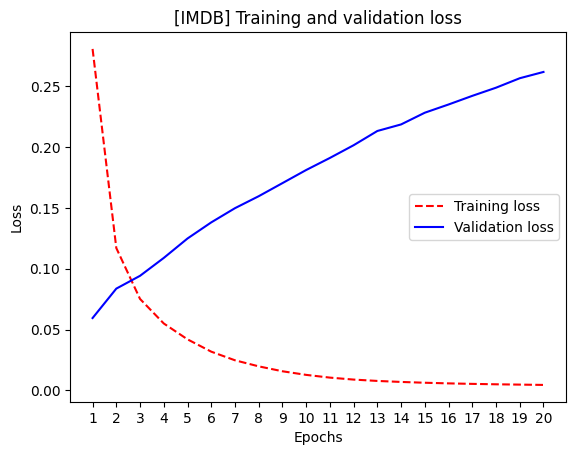

In [22]:
import matplotlib.pyplot as plt

history_dict = history.history
loss_values = history_dict["loss"] # epoch 별 traning loss
val_loss_values = history_dict["val_loss"] # epoch 별 validation loss
epochs = range(1, len(loss_values) + 1)
plt.plot(epochs, loss_values, "r--", label="Training loss")
plt.plot(epochs, val_loss_values, "b", label="Validation loss")
plt.title("[IMDB] Training and validation loss")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Loss")
plt.legend()
plt.show() # overfitting 발생 그래프

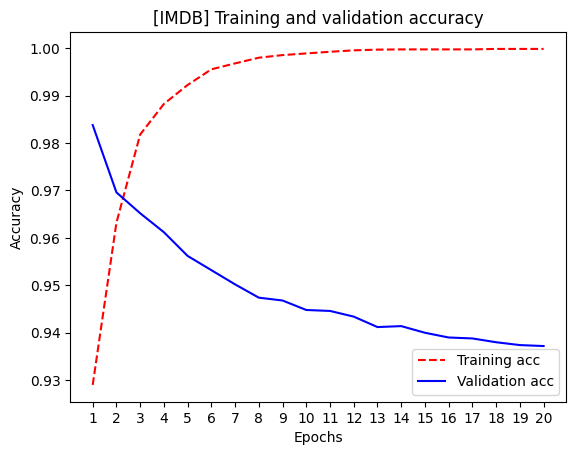

In [23]:
plt.clf()
acc = history_dict["accuracy"]
val_acc = history_dict["val_accuracy"]
plt.plot(epochs, acc, "r--", label="Training acc")
plt.plot(epochs, val_acc, "b", label="Validation acc")
plt.title("[IMDB] Training and validation accuracy")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Accuracy")
plt.legend()
plt.show() # overfitting 발생시 traning acc는 계속 증가, validation accuracy는 어느순간 정체하면서 감소

In [24]:
model = keras.Sequential(
    [
        layers.Dense(16, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
model.fit(x_train, y_train, epochs=4, batch_size=512) # overfitting 방지 위해 4까지만 학습
results = model.evaluate(x_test, y_test) #최종 모델 성능 평가

Epoch 1/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.8122 - loss: 0.4818
Epoch 2/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9088 - loss: 0.2499
Epoch 3/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9357 - loss: 0.1824
Epoch 4/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9521 - loss: 0.1447
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8761 - loss: 0.3188


In [25]:
results # test loss, test acc

[0.3187500834465027, 0.8761199712753296]

Training
→ 모델 학습

Validation
→ 적절한 epoch 결정
   "4 epoch 정도가 좋겠다"

↓

새 모델을 전체 Training data로 4 epochs 학습

↓

Test
→ 최종 성능 평가

#### Using a trained model to generate predictions on new data

In [26]:
model.predict(x_test) # 각각의 데이터에 대해 모델이 실제로 무슨 값을 출력하는가?

782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


array([[0.16872412],
       [0.99997294],
       [0.66594934],
       ...,
       [0.07830435],
       [0.05778402],
       [0.67504096]], dtype=float32)

#### Further experiments

#### Wrapping up

### Classifying newswires: A multiclass classification example

#### The Reuters dataset

In [27]:
from keras.datasets import reuters

(train_data, train_labels), (test_data, test_labels) = reuters.load_data(
    num_words=10000
)

2110848/2110848 ━━━━━━━━━━━━━━━━━━━━ 1s 1us/step


In [28]:
len(train_data)

8982

In [29]:
len(test_data)

2246

In [30]:
train_data[10]

[1,
 245,
 273,
 207,
 156,
 53,
 74,
 160,
 26,
 14,
 46,
 296,
 26,
 39,
 74,
 2979,
 3554,
 14,
 46,
 4689,
 4329,
 86,
 61,
 3499,
 4795,
 14,
 61,
 451,
 4329,
 17,
 12]

In [31]:
word_index = reuters.get_word_index()
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])
decoded_newswire = " ".join(
    [reverse_word_index.get(i - 3, "?") for i in train_data[10]]
) # 숫자 -> 단어 ( 앞 코드와 동일 )

550378/550378 ━━━━━━━━━━━━━━━━━━━━ 1s 2us/step


In [32]:
train_labels[10]  # 46개 class 존재 (숫자 의미 x)

np.int64(3)

#### Preparing the data

In [34]:
x_train = multi_hot_encode(train_data, num_classes=10000)
x_test = multi_hot_encode(test_data, num_classes=10000) # 10,000차원 벡터 생성

In [36]:
def one_hot_encode(labels, num_classes=46):
    results = np.zeros((len(labels), num_classes))
    for i, label in enumerate(labels):
        results[i, label] = 1.0
    return results

y_train = one_hot_encode(train_labels)
y_test = one_hot_encode(test_labels)

# # 정답 class 위치만 1이고 나머지는 모두 0 -> 뉴스 하나의 정답 class가 하나뿐이기 때문에
# one_hot_encode 사용 ( 위에서는 여러 단어 등장 -> mutli_hot_encode 사용 )

In [39]:
from keras.utils import to_categorical # to_categorical이 알아서 변환해줌 (실전용)

y_train = to_categorical(train_labels)
y_test = to_categorical(test_labels)

#### Building your model

In [40]:
model = keras.Sequential(
    [
        layers.Dense(64, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(46, activation="softmax"), # softmax -> 46개 출력이 각각 해당 class 처럼 해석가능한 값이 된다. 전체합 = 1
    ]
)

In [41]:
top_3_accuracy = keras.metrics.TopKCategoricalAccuracy(
    k=3, name="top_3_accuracy"
)
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy", top_3_accuracy],
)

#### Validating your approach

In [43]:
x_val = x_train[:1000] # validation set 만들기
partial_x_train = x_train[1000:]
y_val = y_train[:1000]
partial_y_train = y_train[1000:]

In [44]:
history = model.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val),
)
# 구조 동일

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 261ms/step - accuracy: 0.4084 - loss: 3.4527 - top_3_accuracy: 0.5177 - val_accuracy: 0.5790 - val_loss: 2.7314 - val_top_3_accuracy: 0.6860
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6201 - loss: 2.1602 - top_3_accuracy: 0.7296 - val_accuracy: 0.6340 - val_loss: 1.7036 - val_top_3_accuracy: 0.7580
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7121 - loss: 1.4023 - top_3_accuracy: 0.8038 - val_accuracy: 0.7210 - val_loss: 1.3022 - val_top_3_accuracy: 0.8190
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7739 - loss: 1.0608 - top_3_accuracy: 0.8550 - val_accuracy: 0.7530 - val_loss: 1.1417 - val_top_3_accuracy: 0.8580
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8190 - loss: 0.8405 - top_3_accuracy: 0.8968 - val_accuracy: 0.7730 - val_loss: 1.0435 - val_top_3_accuracy: 0.8790
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8582 - loss: 0.6691 - top_3_a

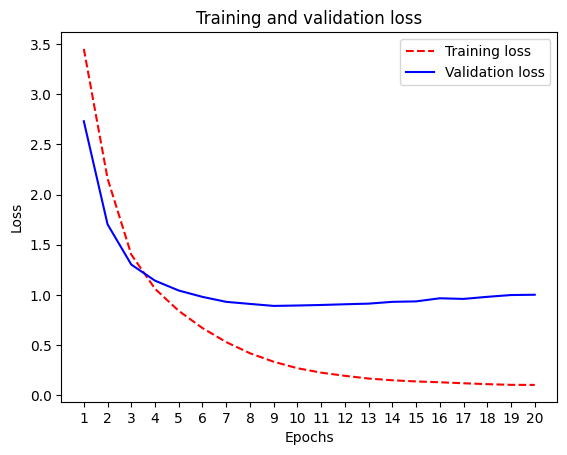

In [45]:
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, "r--", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Loss")
plt.legend()
plt.show()
# validation loss가 다시 올라가는 지점부터 overfitting 의심

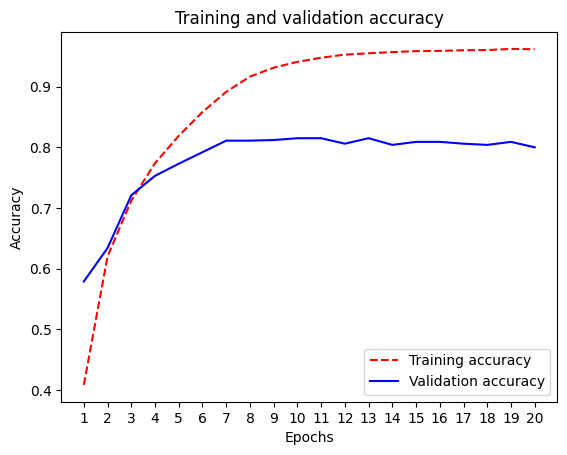

In [46]:
plt.clf()
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
plt.plot(epochs, acc, "r--", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Accuracy")
plt.legend()
plt.show()
#traning acc는 계속 좋아지지만, validation acc가 개선되지 않는다면 overfitting이 진행중

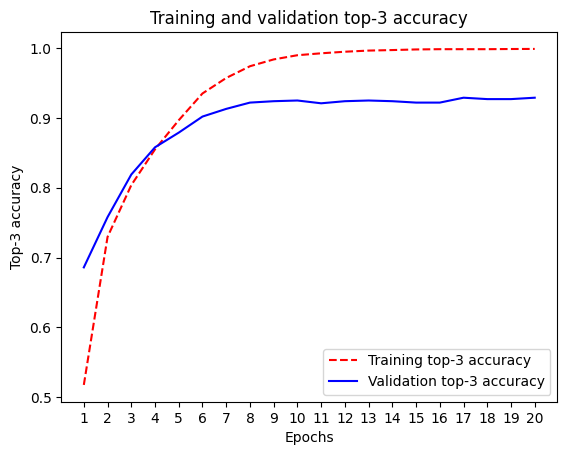

In [47]:
plt.clf()
acc = history.history["top_3_accuracy"]
val_acc = history.history["val_top_3_accuracy"]
plt.plot(epochs, acc, "r--", label="Training top-3 accuracy")
plt.plot(epochs, val_acc, "b", label="Validation top-3 accuracy")
plt.title("Training and validation top-3 accuracy")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Top-3 accuracy")
plt.legend()
plt.show()

In [48]:
model = keras.Sequential(
    [
        layers.Dense(64, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(46, activation="softmax"),
    ]
)
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(
    x_train,
    y_train,
    epochs=9,
    batch_size=512,
)
results = model.evaluate(x_test, y_test)

Epoch 1/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 93ms/step - accuracy: 0.4214 - loss: 3.3461
Epoch 2/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6011 - loss: 2.0147
Epoch 3/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7206 - loss: 1.3277
Epoch 4/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7879 - loss: 0.9924
Epoch 5/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8353 - loss: 0.7713
Epoch 6/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8800 - loss: 0.5932
Epoch 7/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9089 - loss: 0.4621
Epoch 8/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9263 - loss: 0.3604
Epoch 9/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9374 - loss: 0.2894
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8032 - loss: 0.9278


In [49]:
results

[0.9277660250663757, 0.8032057285308838]

In [50]:
import copy
test_labels_copy = copy.copy(test_labels)
np.random.shuffle(test_labels_copy)
hits_array = np.array(test_labels == test_labels_copy)
hits_array.mean()
# 랜덤하게 맞혔을때 어느정도 정확하게 나오는가 -> baseline (최소기준치)

np.float64(0.17764915405164738)

#### Generating predictions on new data

In [51]:
predictions = model.predict(x_test)

71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [52]:
predictions[0].shape

(46,)

In [53]:
np.sum(predictions[0])

np.float32(0.9999998)

In [54]:
np.argmax(predictions[0])

np.int64(3)

#### A different way to handle the labels and the loss

In [55]:
y_train = train_labels
y_test = test_labels

In [56]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

#### The importance of having sufficiently large intermediate layers

In [57]:
model = keras.Sequential(
    [
        layers.Dense(64, activation="relu"),
        layers.Dense(4, activation="relu"), # 뉴런 4개 -> 많은 정보를 4차원 공간에 압축 (information bottleneck 발생)
        layers.Dense(46, activation="softmax"),
    ]
)
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=128,
    validation_data=(x_val, y_val),
)

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - accuracy: 0.1367 - loss: 2.9944 - val_accuracy: 0.5750 - val_loss: 2.1405
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5923 - loss: 1.6989 - val_accuracy: 0.6020 - val_loss: 1.5114
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6398 - loss: 1.2981 - val_accuracy: 0.6540 - val_loss: 1.3543
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7211 - loss: 1.0971 - val_accuracy: 0.6790 - val_loss: 1.2920
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7484 - loss: 0.9599 - val_accuracy: 0.6840 - val_loss: 1.2679
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7646 - loss: 0.8585 - val_accuracy: 0.6940 - val_loss: 1.2609
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7791 - loss: 0.7781 - val_accuracy: 0.7040 - val_loss: 1.2634
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7964 - loss: 0.7084 - val_accuracy: 0.7080 - val_loss

① One-hot Encoding

class 3
→ [0,0,0,1,0,...]


② Softmax

46개 값
→ 46개 class의 확률분포


③ Categorical Crossentropy

One-hot label
→ categorical_crossentropy

Integer label
→ sparse_categorical_crossentropy


④ Information Bottleneck

중간 layer가 지나치게 작음
→ 정보 손실
→ 분류 성능 저하 가능

#### Further experiments

#### Wrapping up

### Predicting house prices: A regression example

#### The California Housing Price dataset

In [61]:
from keras.datasets import california_housing

(train_data, train_targets), (test_data, test_targets) = (
    california_housing.load_data(version="small")
) # class label -> 연속적인 숫자값으로 변경

743530/743530 ━━━━━━━━━━━━━━━━━━━━ 1s 1us/step


In [58]:
train_data.shape

(8982,)

In [59]:
test_data.shape

(2246,)

In [62]:
train_targets

array([228400., 132900.,  60000.,  95200., 107000., 122500., 132000.,
       290100., 257800., 390100., 220800., 284900.,  97500., 415300.,
        84200., 185600., 216700., 233100., 127000., 182300.,  92300.,
        90700., 102100., 112500., 350700., 156500., 220700., 147400.,
       216700., 275000., 198200., 119100., 289500., 152500., 125000.,
       104500.,  93800.,  89300., 452600., 128600., 311500.,  90000.,
       218200., 131300.,  67500., 139400., 500001., 182600., 111300.,
       112500., 134700.,  71300., 207400., 331400., 107900.,  87500.,
       342200.,  87100., 314700., 368600., 211600., 338900., 366100.,
       164300.,  91700., 261400., 218500., 155400., 273700.,  81800.,
       138800.,  99700., 156300., 140600., 152700., 108900., 351200.,
       126000., 137500., 196900., 240000., 172800., 254200.,  97500.,
       182700., 162500.,  86100., 226700., 412500., 165900., 327100.,
       162500., 188800., 183800.,  90600., 372000., 275000., 151800.,
       125000., 1291

#### Preparing the data

In [68]:
mean = train_data.mean(axis=0)
std = train_data.std(axis=0)
x_train = (train_data - mean) / std
x_test = (test_data - mean) / std
# feature들의 scale차이가 큼 -> 모든 feature를 비슷한 scale로 바꿔주는 표준화 작업

In [69]:
y_train = train_targets / 100000
y_test = test_targets / 100000
# 너무 큰 숫자를 다루지 않도록 target의 scale을 줄여준다.

#### Building your model

In [70]:
def get_model(): # k - fold validation 을하면서 새로운 model을 여러번 만들기 위해 사용
    model = keras.Sequential(
        [
            layers.Dense(64, activation="relu"),
            layers.Dense(64, activation="relu"),
            layers.Dense(1), # 집값 하나를 예측하기때문에 출력도 하나
        ] # sigmoid를 쓰면 출력이 0~1로 제한, 따라서 자유로운 숫자예측을 위해 activation 사용 x
    )
    model.compile(
        optimizer="adam",
        loss="mean_squared_error",
        metrics=["mean_absolute_error"],
    )
    return model

#### Validating your approach using K-fold validation

In [77]:
k = 4    # 4-fold validation
num_val_samples = len(x_train) // k # fold 하나의 크기 구하기
num_epochs = 50
all_scores = []
for i in range(k):
    print(f"Processing fold #{i + 1}")

    # 현재 fold에서 사용할 validation 부분을 잘라낸다.
    fold_x_val = x_train[i * num_val_samples : (i + 1) * num_val_samples]
    fold_y_val = y_train[i * num_val_samples : (i + 1) * num_val_samples]

    # 현재 validation 으로 사용하는 부분만 빼고 나머지를 다시 합친다.
    fold_x_train = np.concatenate(
        [x_train[: i * num_val_samples], x_train[(i + 1) * num_val_samples :]],
        axis=0,
    )
    fold_y_train = np.concatenate(
        [y_train[: i * num_val_samples], y_train[(i + 1) * num_val_samples :]],
        axis=0,
    )
    model = get_model()
    model.fit(
        fold_x_train,
        fold_y_train,
        epochs=num_epochs,
        batch_size=16,
        verbose=0, # 학습과정 출력 숨기기
    )
    scores = model.evaluate(fold_x_val, fold_y_val, verbose=0)
    val_loss, val_mae = scores
    all_scores.append(val_mae)

Processing fold #1
Processing fold #2
Processing fold #3
Processing fold #4


In [78]:
[round(value, 3) for value in all_scores]

[0.304, 0.282, 0.243, 0.321]

In [80]:
round(np.mean(all_scores), 3) # 4개 mae의 평균 구하기 -> k fold validation의 최종 평가값

np.float64(0.287)

In [81]:
k = 4
num_val_samples = len(x_train) // k
num_epochs = 200
all_mae_histories = []
for i in range(k):
    print(f"Processing fold #{i + 1}")
    fold_x_val = x_train[i * num_val_samples : (i + 1) * num_val_samples]
    fold_y_val = y_train[i * num_val_samples : (i + 1) * num_val_samples]
    fold_x_train = np.concatenate(
        [x_train[: i * num_val_samples], x_train[(i + 1) * num_val_samples :]],
        axis=0,
    )
    fold_y_train = np.concatenate(
        [y_train[: i * num_val_samples], y_train[(i + 1) * num_val_samples :]],
        axis=0,
    )
    model = get_model()
    history = model.fit(
        fold_x_train,
        fold_y_train,
        validation_data=(fold_x_val, fold_y_val),
        epochs=num_epochs,
        batch_size=16,
        verbose=0,
    )
    mae_history = history.history["val_mean_absolute_error"]
    all_mae_histories.append(mae_history)

Processing fold #1
Processing fold #2
Processing fold #3
Processing fold #4


In [83]:
average_mae_history = [
    np.mean([x[i] for x in all_mae_histories]) for i in range(num_epochs)
]

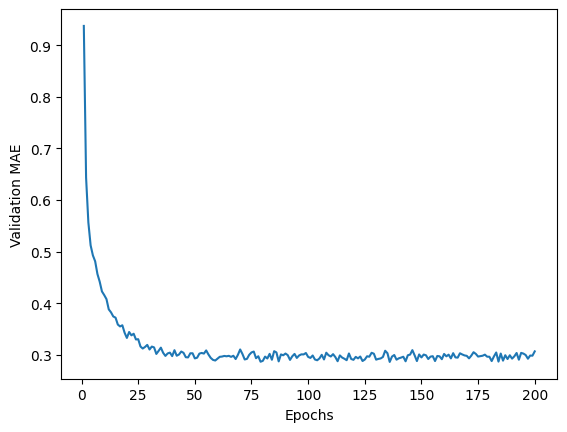

In [84]:
epochs = range(1, len(average_mae_history) + 1)
plt.plot(epochs, average_mae_history)
plt.xlabel("Epochs")
plt.ylabel("Validation MAE")
plt.show()

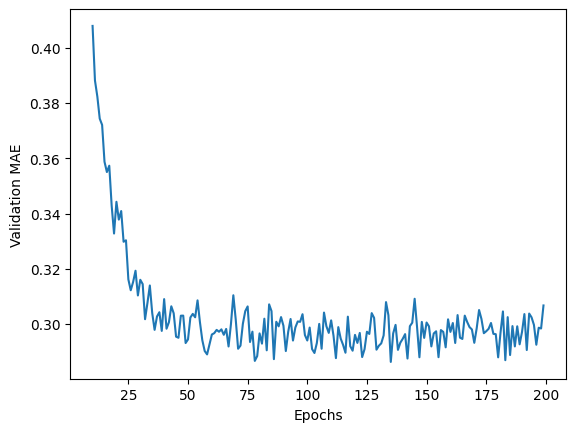

In [85]:
truncated_mae_history = average_mae_history[10:] # 너무데이터가 많아서 앞에 10개 버리고 시작
epochs = range(10, len(truncated_mae_history) + 10)
plt.plot(epochs, truncated_mae_history)
plt.xlabel("Epochs")
plt.ylabel("Validation MAE")
plt.show()

In [86]:
model = get_model()
model.fit(x_train, y_train, epochs=130, batch_size=16, verbose=0)
test_mean_squared_error, test_mean_absolute_error = model.evaluate(
    x_test, y_test
)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.2995 - mean_absolute_error: 0.3221


In [87]:
round(test_mean_absolute_error, 3)

0.322

K-fold Validation
      ↓

적절한 Epoch 찾음
      ↓

130 epochs 결정
      ↓

새 모델 생성
      ↓

전체 Training data로 학습
      ↓
      
Test data 최종 평가

#### Generating predictions on new data

In [88]:
predictions = model.predict(x_test)
predictions[0]

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


array([2.7424839], dtype=float32)

#### Wrapping up